Sto schifo va reso presentabile

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import plotly.graph_objects as go
import math
import textwrap

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

Load the pre- processed dataset

In [46]:
df = pd.read_csv('Datasets/Processed/Erasmus-Data.csv', index_col=0, low_memory=False)
df = df.reset_index(drop=True)
print(df.shape)
df.head()

(3172958, 14)


,Academic Year,Mobility Duration,Field of Education,Participant Country,Education Level,Participant Gender,Fewer Opportunities,Participant Age,Sending Country,Sending City,Sending Organization,Receiving Country,Receiving City,Receiving Organization
0,2023,61,Business and administration,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,0,22,Austria,WIEN,WU,Germany,Munich,-
1,2023,101,Economics,Germany,ISCED-7 - Second cycle / Master’s or equivalen...,Male,0,27,Austria,WIEN,WU,France,Toulouse,Université Toulouse Capitole
2,2023,121,Business and administration,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,0,22,Austria,WIEN,WU,France,Paris,-
3,2023,171,Business and administration,Germany,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,0,22,Austria,WIEN,WU,France,Paris,-
4,2023,86,Business and administration,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,0,23,Austria,WIEN,WU,Germany,Hamburg,-


## 2. Analisi Esplorativa e Visualizzazione
*Durata : 12 minuti*

Ripetiamo lo stesso set di analisi - collegate alle 3 domande della sezione 0 - su tre livelli
via via piu specifici: **Europa -> Italia -> UMIL**, arricchendo ogni livello con una feature
specifica ().


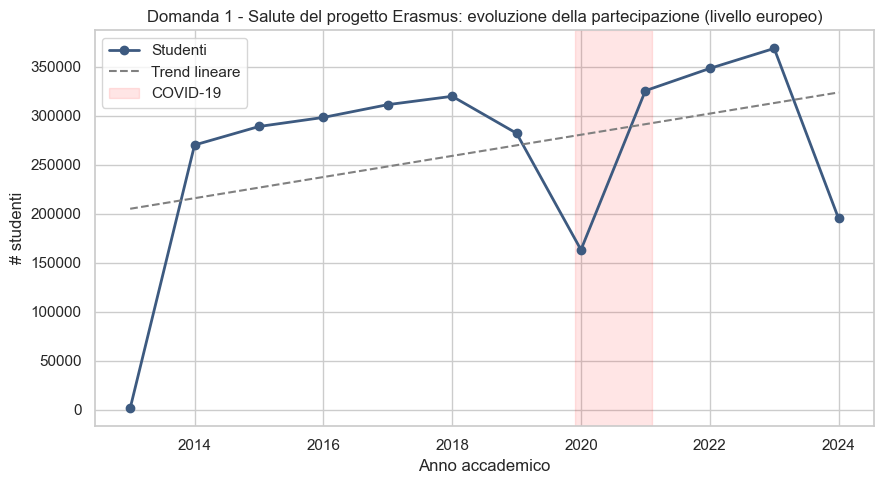

In [ ]:
yearly = df.groupby('Academic Year').size()
years, counts = yearly.index.values, yearly.values

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(years, counts, marker='o', color='#3d5a80', linewidth=2, label='Studenti')
z = np.polyfit(years, counts, 1)
ax.plot(years, np.poly1d(z)(years), '--', color='gray', label='Trend lineare')
ax.axvspan(2019.9, 2021.1, color='red', alpha=0.1, label='COVID-19')
ax.set_title('Domanda 1 - Salute del progetto Erasmus: evoluzione della partecipazione (livello europeo)')
ax.set_xlabel('Anno accademico'); ax.set_ylabel('# studenti'); ax.legend()
plt.tight_layout(); plt.show()

Beginning of Chloropeth Map

Bla Bla Bla about Chloropeth

In [ ]:
# ---------------------------------------------------------------------------
# Build per-year incoming-student counts
# ---------------------------------------------------------------------------
years = sorted(df["Academic Year"].astype(str).str[:4].astype(int).unique())

incoming_by_year = {}
for year in years:
    df_year = df[df["Academic Year"].astype(str).str[:4].astype(int) == year]
    incoming = (
        df_year.groupby("Receiving Country")
               .size()
               .reset_index(name="incoming")
               .rename(columns={"Receiving Country": "Country"})
    )
    incoming_by_year[year] = incoming

# ---------------------------------------------------------------------------
# Load and clean the map geometry
# ---------------------------------------------------------------------------
world = gpd.read_file("Datasets/ne_110m_admin_0_countries.zip")

# Standardize names across shapefile definitions
world["NAME"] = world["NAME"].replace({
    "Türkiye": "Turkey", 
    "Czechia": "Czech Republic",
    "Bosnia and Herz.": "Bosnia and Herzegovina",
    "Russian Federation": "Russia",
    "Moldova, Republic of": "Moldova"
})

europe_list = [
    "Albania", "Andorra", "Austria", "Belgium", "Bosnia and Herzegovina", "Bulgaria",
    "Croatia", "Cyprus", "Czech Republic", "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Iceland", "Ireland", "Italy", "Kosovo", "Latvia", "Liechtenstein",
    "Lithuania", "Luxembourg", "Malta", "Moldova", "Monaco", "Montenegro", "Netherlands",
    "North Macedonia", "Norway", "Poland", "Portugal", "Romania", "San Marino", "Serbia",
    "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland", "Turkey", "Ukraine", "United Kingdom",
    "Vatican"
]
europe = world[world["NAME"].isin(europe_list)].copy()

# ---------------------------------------------------------------------------
# Global Color Scale settings
# ---------------------------------------------------------------------------
GLOBAL_MAX = max(d["incoming"].max() for d in incoming_by_year.values() if not d.empty)
GLOBAL_MAX = math.ceil(GLOBAL_MAX / 1000) * 1000

COLORSCALE = "YlOrRd"  
COUNTRY_LINE_COLOR = "white"

# ---------------------------------------------------------------------------
# Build year data
# ---------------------------------------------------------------------------
def build_year_data(year):
    year_df = incoming_by_year[year].copy()
    
    merged = europe.merge(year_df, left_on="NAME", right_on="Country", how="left")
    merged = merged.sort_values("NAME").reset_index(drop=True)
    
    merged["hover"] = (
        "<b>" + merged["NAME"] + "</b><br>" +
        "Incoming students: " + 
        merged["incoming"].apply(lambda x: f"{int(x):,}" if pd.notna(x) else "No data")
    )
    return merged

frames_data = {year: build_year_data(year) for year in years}

def make_trace(data_year, showscale=True):
    return go.Choropleth(
        locations=data_year["NAME"],
        z=data_year["incoming"],
        text=data_year["hover"],
        hovertemplate="%{text}<extra></extra>",
        locationmode="country names",
        colorscale=COLORSCALE,
        zmin=0,
        zmax=GLOBAL_MAX,
        marker_line_color=COUNTRY_LINE_COLOR,
        marker_line_width=0.8,
        showscale=showscale,
        colorbar=dict(
            title=dict(text="Students", font=dict(size=12, color="#444")),
            thickness=15,
            len=0.9,               # Proportionally scales colorbar height relative to the graph
            x=0.92,                # Adjusted inwards so it stays safe inside the width bounds
            y=0.5,                 # Centers vertically
            yanchor="middle",
            tickfont=dict(size=11, color="#555"),
            outlinewidth=0,
        ),
    )

# ---------------------------------------------------------------------------
# Frames (Dynamic Title Updates)
# ---------------------------------------------------------------------------
frames = []
for year in years:
    frames.append(
        go.Frame(
            data=[make_trace(frames_data[year])],
            name=str(year),
            layout=go.Layout(
                # Update the layout title dynamically for each year frame
                title=dict(
                    text=f"<b>Incoming Erasmus Students per Country A.Y {year}</b>"
                )
            ),
        )
    )

first_year = years[0]
fig = go.Figure(
    data=[make_trace(frames_data[first_year])],
    frames=frames,
)

# ---------------------------------------------------------------------------
# Global Layout Configuration
# ---------------------------------------------------------------------------
fig.update_layout(
    title=dict(
        text=f"<b>Incoming Erasmus Students per Country A.Y {first_year}</b>",
        x=0.5, xanchor="center", y=0.94,
        font=dict(size=22, family="Arial", color="#2b2b2b"),
    ),
    font=dict(family="Helvetica Neue, Arial", color="#2b2b2b"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    width=1000,
    height=750,
    margin=dict(l=30, r=30, t=110, b=20),

    geo=dict(
        showframe=False,
        showcoastlines=False,
        showcountries=True,
        countrycolor="white",
        showland=True,
        landcolor="#eef0f2",   
        showocean=False,
        projection_type="natural earth",
        center=dict(lat=53, lon=15),
        lataxis_range=[34, 71],   
        lonaxis_range=[-22, 45],  
        bgcolor="white",
    ),

    sliders=[{
        "active": 0,
        "currentvalue": {
            "prefix": "Academic Year: ",
            "font": {"size": 13, "family": "Arial"},
        },
        "pad": {"t": 30, "b": 15},
        "x": 0.12, "len": 0.76,
        "transition": {"duration": 400, "easing": "cubic-in-out"},
        "steps": [
            {
                "method": "animate",
                "args": [[str(year)], {
                    "frame": {"duration": 400, "redraw": True},
                    "mode": "immediate",
                    "transition": {"duration": 400},
                }],
                "label": str(year),
            }
            for year in years
        ],
    }],

    updatemenus=[{
        "type": "buttons",
        "direction": "left",
        "x": 0.12, "y": 0.02,
        "xanchor": "left", "yanchor": "bottom",
        "showactive": False,
        "font": {"size": 12, "family": "Arial"},
        "bgcolor": "white",
        "bordercolor": "#ddd",
        "borderwidth": 1,
        "buttons": [
            {
                "label": "▶ Play",
                "method": "animate",
                "args": [None, {
                    "frame": {"duration": 800, "redraw": True},
                    "fromcurrent": True,
                    "transition": {"duration": 400},
                }],
            },
            {
                "label": "⏸ Pause",
                "method": "animate",
                "args": [[None], {
                    "frame": {"duration": 0, "redraw": False},
                    "mode": "immediate",
                }],
            },
        ],
    }],
)

fig.show()

C:\Users\raffa\AppData\Local\Temp\ipykernel_7744\1385401613.py:113: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = go.Figure(


Now, onto the outgoing students

___

In [ ]:
# ---------------------------------------------------------------------------
# Build per-year outgoing-student counts
# ---------------------------------------------------------------------------
years = sorted(df["Academic Year"].astype(str).str[:4].astype(int).unique())

outgoing_by_year = {}
for year in years:
    df_year = df[df["Academic Year"].astype(str).str[:4].astype(int) == year]
    outgoing = (
        df_year.groupby("Sending Country")
               .size()
               .reset_index(name="outgoing")
               .rename(columns={"Sending Country": "Country"})
    )
    outgoing_by_year[year] = outgoing

# ---------------------------------------------------------------------------
# Load and clean the map geometry ---> MOVE THIS TO OUTSIDE THE SINGLE GRAPH CELL, MAKE IT GENERAL
# ---------------------------------------------------------------------------
world = gpd.read_file("Datasets/ne_110m_admin_0_countries.zip")

# Standardize names across shapefile definitions
world["NAME"] = world["NAME"].replace({
    "Türkiye": "Turkey", 
    "Czechia": "Czech Republic",
    "Bosnia and Herz.": "Bosnia and Herzegovina",
    "Russian Federation": "Russia",
    "Moldova, Republic of": "Moldova"
})

europe_list = [
    "Albania", "Andorra", "Austria", "Belgium", "Bosnia and Herzegovina", "Bulgaria",
    "Croatia", "Cyprus", "Czech Republic", "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Iceland", "Ireland", "Italy", "Kosovo", "Latvia", "Liechtenstein",
    "Lithuania", "Luxembourg", "Malta", "Moldova", "Monaco", "Montenegro", "Netherlands",
    "North Macedonia", "Norway", "Poland", "Portugal", "Romania", "San Marino", "Serbia",
    "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland", "Turkey", "Ukraine", "United Kingdom",
    "Vatican"
]
europe = world[world["NAME"].isin(europe_list)].copy()

# ---------------------------------------------------------------------------
# Global Color Scale settings
# ---------------------------------------------------------------------------
GLOBAL_MAX = max(d["outgoing"].max() for d in outgoing_by_year.values() if not d.empty)
GLOBAL_MAX = math.ceil(GLOBAL_MAX / 1000) * 1000

COLORSCALE = "YlOrRd"  
COUNTRY_LINE_COLOR = "white"

# ---------------------------------------------------------------------------
# Build year data
# ---------------------------------------------------------------------------
def build_year_data(year):
    year_df = outgoing_by_year[year].copy()
    
    merged = europe.merge(year_df, left_on="NAME", right_on="Country", how="left")
    merged = merged.sort_values("NAME").reset_index(drop=True)
    
    merged["hover"] = (
        "<b>" + merged["NAME"] + "</b><br>" +
        "Outgoing students: " + 
        merged["outgoing"].apply(lambda x: f"{int(x):,}" if pd.notna(x) else "No data")
    )
    return merged

frames_data = {year: build_year_data(year) for year in years}

def make_trace(data_year, showscale=True):
    return go.Choropleth(
        locations=data_year["NAME"],
        z=data_year["outgoing"],
        text=data_year["hover"],
        hovertemplate="%{text}<extra></extra>",
        locationmode="country names",
        colorscale=COLORSCALE,
        zmin=0,
        zmax=GLOBAL_MAX,
        marker_line_color=COUNTRY_LINE_COLOR,
        marker_line_width=0.8,
        showscale=showscale,
        colorbar=dict(
            title=dict(text="Students", font=dict(size=12, color="#444")),
            thickness=15,
            len=0.85,               # Proportionally scales colorbar height relative to the graph
            x=0.92,                # Adjusted inwards so it stays safe inside the width bounds
            y=0.5,                 # Centers vertically
            yanchor="middle",
            tickfont=dict(size=11, color="#555"),
            outlinewidth=0,
        ),
    )

# ---------------------------------------------------------------------------
# Frames (Dynamic Title Updates)
# ---------------------------------------------------------------------------
frames = []
for year in years:
    frames.append(
        go.Frame(
            data=[make_trace(frames_data[year])],
            name=str(year),
            layout=go.Layout(
                # Update the layout title dynamically for each year frame
                title=dict(
                    text=f"<b>Outgoing Erasmus Students per Country A.Y {year}</b>"
                )
            ),
        )
    )

first_year = years[0]
fig = go.Figure(
    data=[make_trace(frames_data[first_year])],
    frames=frames,
)

# ---------------------------------------------------------------------------
# Global Layout Configuration
# ---------------------------------------------------------------------------
fig.update_layout(
    title=dict(
        text=f"<b>Outgoing Erasmus Students per Country A.Y {first_year}</b>",
        x=0.5, xanchor="center", y=0.94,
        font=dict(size=22, family="Garamond", color="#2b2b2b"),
    ),
    font=dict(family="Helvetica Neue, Arial", color="#2b2b2b"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    width=1000,
    height=750,
    margin=dict(l=30, r=30, t=110, b=20),

    geo=dict(
        showframe=False,
        showcoastlines=False,
        showcountries=True,
        countrycolor="white",
        showland=True,
        landcolor="#eef0f2",   
        showocean=False,
        projection_type="natural earth",
        center=dict(lat=53, lon=15),
        lataxis_range=[34, 71],   
        lonaxis_range=[-22, 45],  
        bgcolor="white",
    ),

    sliders=[{
        "active": 0,
        "currentvalue": {
            "prefix": "Academic Year: ",
            "font": {"size": 13, "family": "Garamond"},
        },
        "pad": {"t": 30, "b": 15},
        "x": 0.12, "len": 0.76,
        "transition": {"duration": 400, "easing": "cubic-in-out"},
        "steps": [
            {
                "method": "animate",
                "args": [[str(year)], {
                    "frame": {"duration": 400, "redraw": True},
                    "mode": "immediate",
                    "transition": {"duration": 400},
                }],
                "label": str(year),
            }
            for year in years
        ],
    }],

    updatemenus=[{
        "type": "buttons",
        "direction": "left",
        "x": 0.12, "y": 0.02,
        "xanchor": "left", "yanchor": "bottom",
        "showactive": False,
        "font": {"size": 12, "family": "Garamond"},
        "bgcolor": "white",
        "bordercolor": "#ddd",
        "borderwidth": 1,
        "buttons": [
            {
                "label": "▶ Play",
                "method": "animate",
                "args": [None, {
                    "frame": {"duration": 800, "redraw": True},
                    "fromcurrent": True,
                    "transition": {"duration": 400},
                }],
            },
            {
                "label": "⏸ Pause",
                "method": "animate",
                "args": [[None], {
                    "frame": {"duration": 0, "redraw": False},
                    "mode": "immediate",
                }],
            },
        ],
    }],
)

fig.show()

C:\Users\raffa\AppData\Local\Temp\ipykernel_7744\929106091.py:113: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = go.Figure(


Heatmap

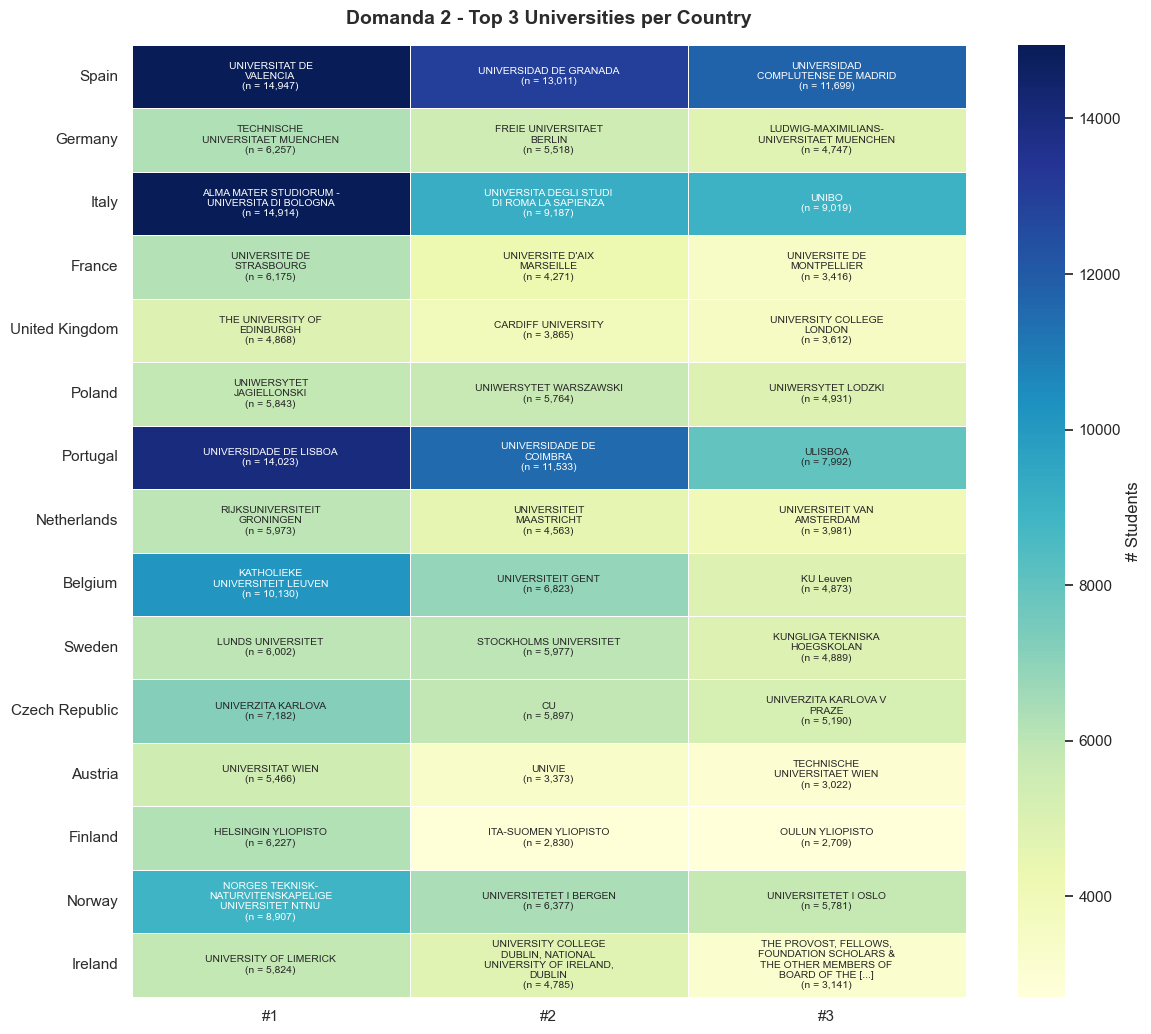

In [79]:
# Identify the top 15 receiving countries by TOTAL volume
top_countries = df['Receiving Country'].value_counts().head(15).index

# Filter out invalid university names
univ_column = 'Receiving Organization'
is_valid_org = (
    df[univ_column].notna() &                                      
    (df[univ_column].astype(str).str.strip() != '') &              
    (df[univ_column].astype(str).str.strip() != '-') &             
    (~df[univ_column].astype(str).str.upper().isin(['N/D', 'N/A', 'UNKNOWN'])) 
)
df_valid_orgs = df[is_valid_org]

# 4. Build Matrices
mat = pd.DataFrame(index=top_countries, columns=['#1', '#2', '#3'], dtype=float)
labels = pd.DataFrame(index=top_countries, columns=['#1', '#2', '#3'], dtype=object)

for c in top_countries:
    sub = df_valid_orgs[df_valid_orgs['Receiving Country'] == c]
    top3 = sub[univ_column].value_counts().head(3)
    
    for i, (org, n) in enumerate(top3.items()):
        mat.loc[c, f'#{i+1}'] = n
        
        # FIX: Wrap text dynamically every 22 characters instead of slicing it
        wrapped_org_name = textwrap.fill(str(org), width = 22, max_lines = 4)
        
        labels.loc[c, f'#{i+1}'] = f"{wrapped_org_name}\n(n = {int(n):,})"

mat = mat.fillna(0)
labels = labels.fillna('')

# 5. Plotting (Adjusted height and font size for wrapped text comfort)
plt.figure(figsize=(12, 10.5)) 
plt.rcParams['font.family'] = 'sans-serif'

ax = sns.heatmap(
    mat, 
    annot=labels, 
    fmt='', 
    cmap='YlGnBu', 
    linewidths=0.6, 
    linecolor='white',
    cbar_kws={'label': '# Students'}, 
    annot_kws={'fontsize': 7.5, 'weight': 'normal'}
    )

ax.set_title('Domanda 2 - Top 3 Universities per Country', 
             fontsize=14, pad=15, weight='bold', color='#2b2b2b')
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='both', which='major', labelsize=11, labelcolor='#2b2b2b')

plt.tight_layout()
plt.show()

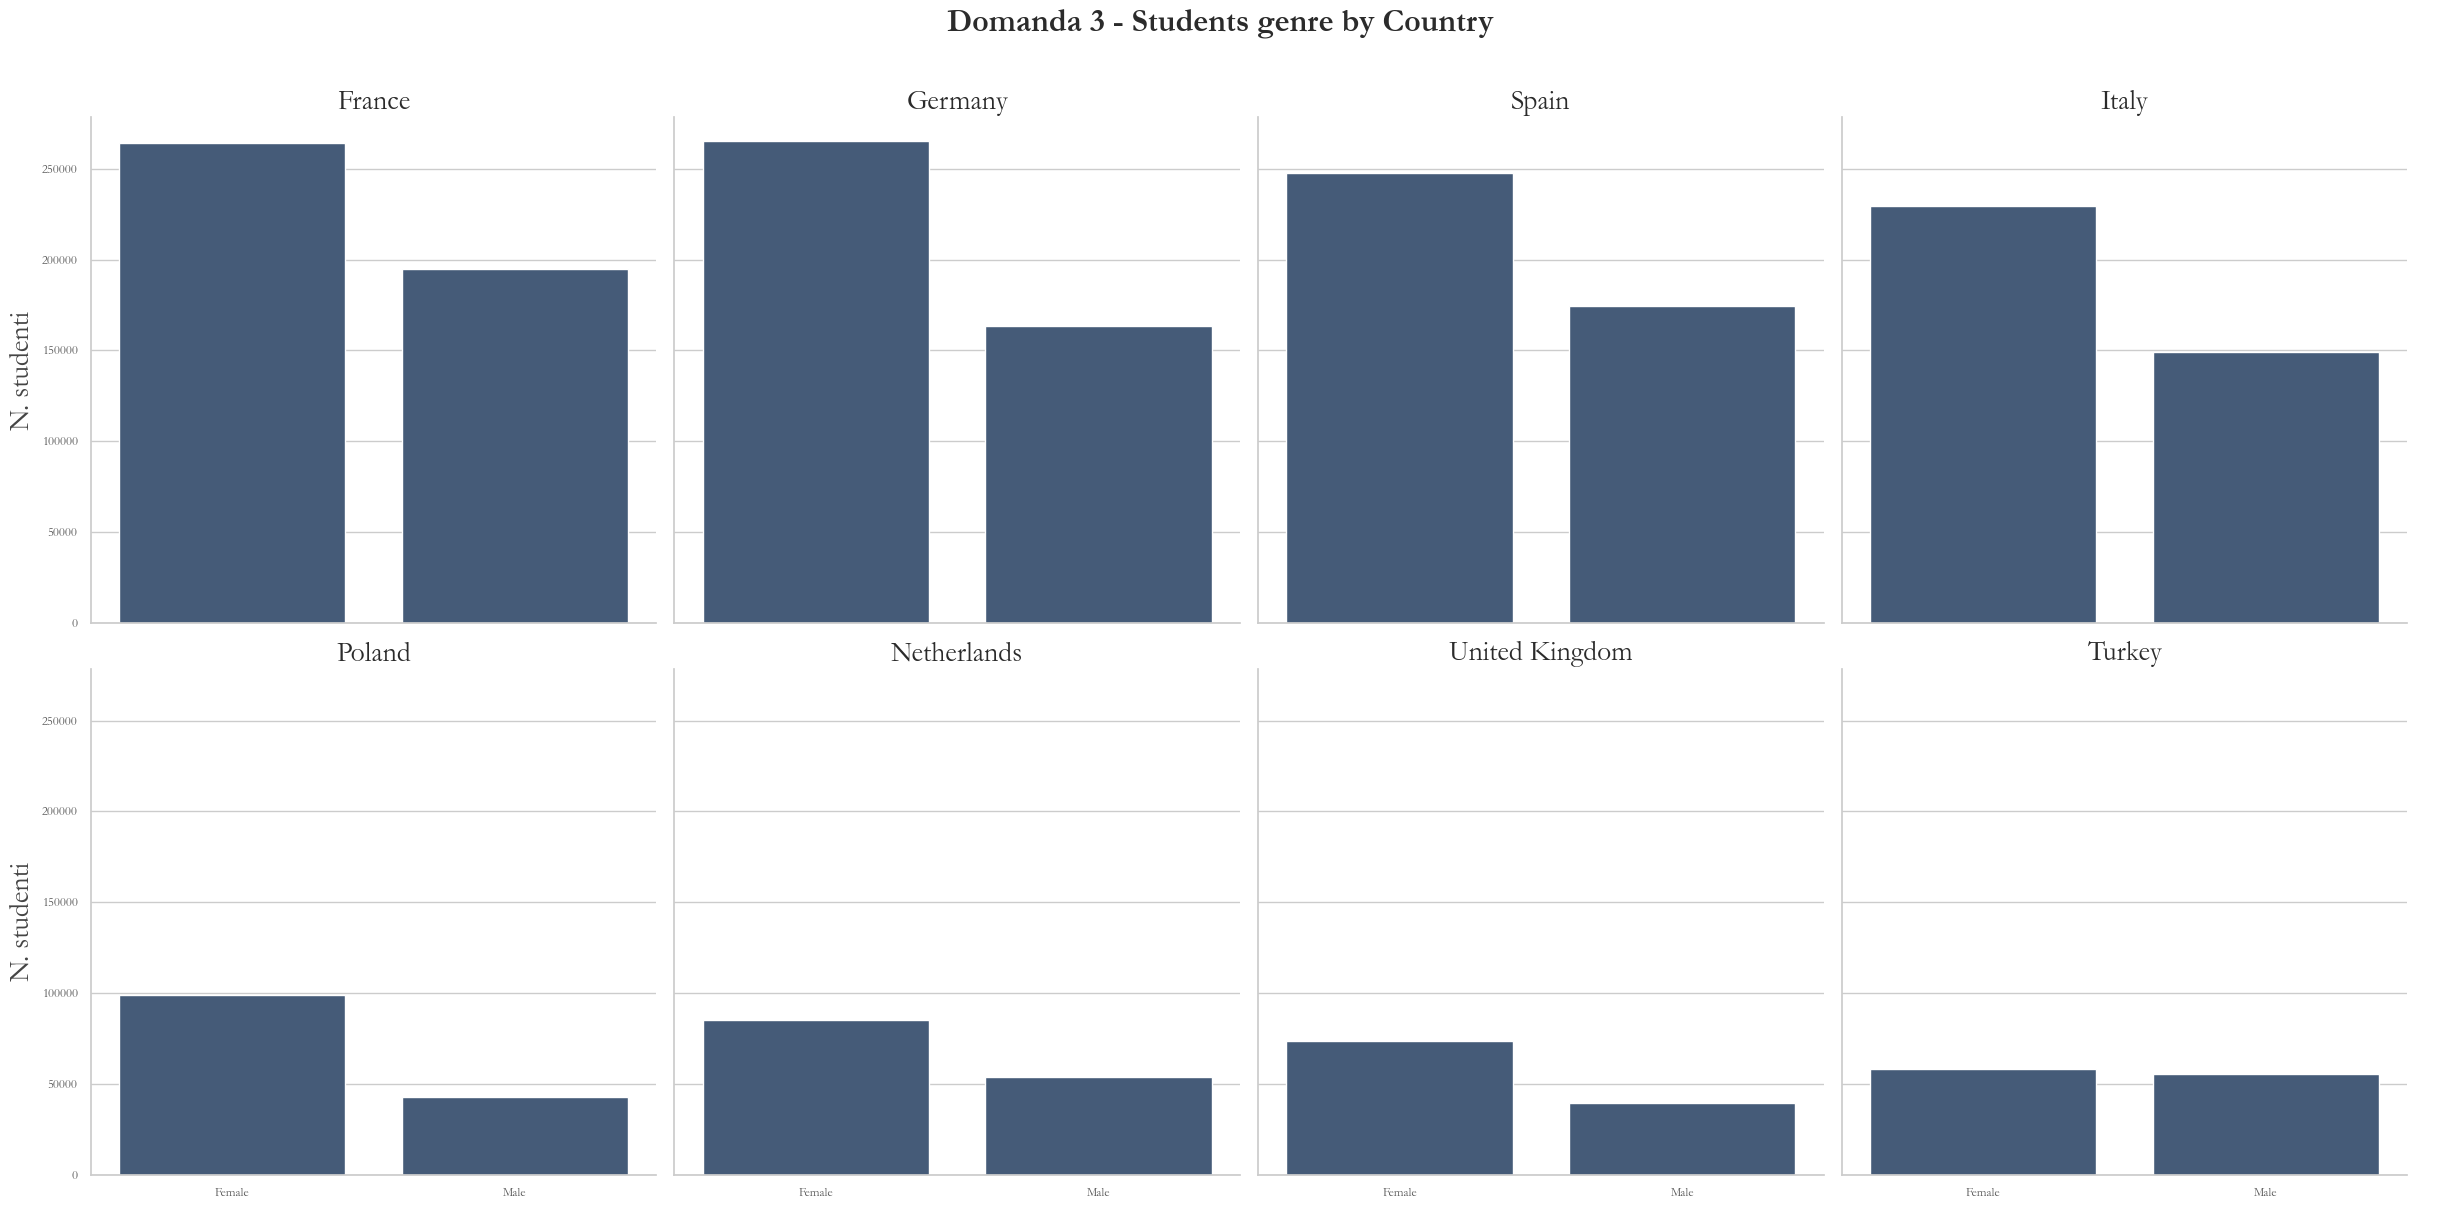

In [68]:
country_col = 'Sending Country'  # Adjusted from 'SendingCountryName' to match your column style

# ---------------------------------------------------------------------------
# 2. Filter for Top 8 Countries and Valid Genders
# ---------------------------------------------------------------------------
top_countries8 = df[country_col].value_counts().head(8).index
sub = df[df[country_col].isin(top_countries8) & df['Participant Gender'].isin(['Male', 'Female'])]

# ---------------------------------------------------------------------------
# 3. Plotting the Facet Grid (Catplot)
# ---------------------------------------------------------------------------
# Set a clean, professional aesthetic background
sns.set_theme(style="whitegrid", font="Garamond")

g = sns.catplot(
    data=sub, 
    x='Participant Gender', 
    col=country_col, 
    col_wrap=4,
    kind='count', 
    height=5.8, 
    aspect=1.05, 
    color='#3d5a80', 
    col_order=top_countries8
)

# Refine subplots layout and typography
g.set_titles("{col_name}", size=20, color='#2b2b2b')
g.set_axis_labels("", "N. studenti", size=20, color='#444')

# Clean up the tick labels
for ax in g.axes.flat:
    ax.tick_params(labelsize=9, labelcolor='#555')
    ax.xaxis.grid(False) # Remove vertical gridlines for a cleaner look

# Main title with proper padding and weight
g.figure.suptitle(
    "Domanda 3 - Students genre by Country", 
    y=1.06, 
    fontsize=23, 
    weight='bold', 
    color='#2b2b2b'
)

plt.show()